# 01 – EDA & Preprocessing
Dataset: MS-COCO train2017 (118k images, ~591k captions)

In [8]:
# !pip install kaggle nltk wordcloud -q
import os, re, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
from tqdm.auto import tqdm

## 1. Download COCO train2017

In [9]:
# Place kaggle.json in ~/.kaggle/ then run:
# !kaggle datasets download -d awsaf49/coco-2017-dataset -p data/ --unzip

COCO_IMGS  = 'data/coco2017/train2017'
COCO_ANNOT = 'data/coco2017/annotations/captions_train2017.json'

## 2. Load captions

In [10]:
with open(COCO_ANNOT) as f:
    raw = json.load(f)

id2file = {img['id']: img['file_name'] for img in raw['images']}

rows = []
for ann in raw['annotations']:
    rows.append({
        'image'  : os.path.join(COCO_IMGS, id2file[ann['image_id']]),
        'caption': ann['caption'],
    })

df = pd.DataFrame(rows)
print(f"Total pairs   : {len(df):,}")
print(f"Unique images : {df['image'].nunique():,}")
df.head(3)

Total pairs   : 591,753
Unique images : 118,287


,image,caption
0,data/coco2017/train2017/000000203564.jpg,A bicycle replica with a clock as the front wh...
1,data/coco2017/train2017/000000322141.jpg,A room with blue walls and a white sink and door.
2,data/coco2017/train2017/000000016977.jpg,A car that seems to be parked illegally behind...


## 3. Caption preprocessing

In [11]:
def clean(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df['caption_clean'] = df['caption'].apply(clean)

## 4. EDA

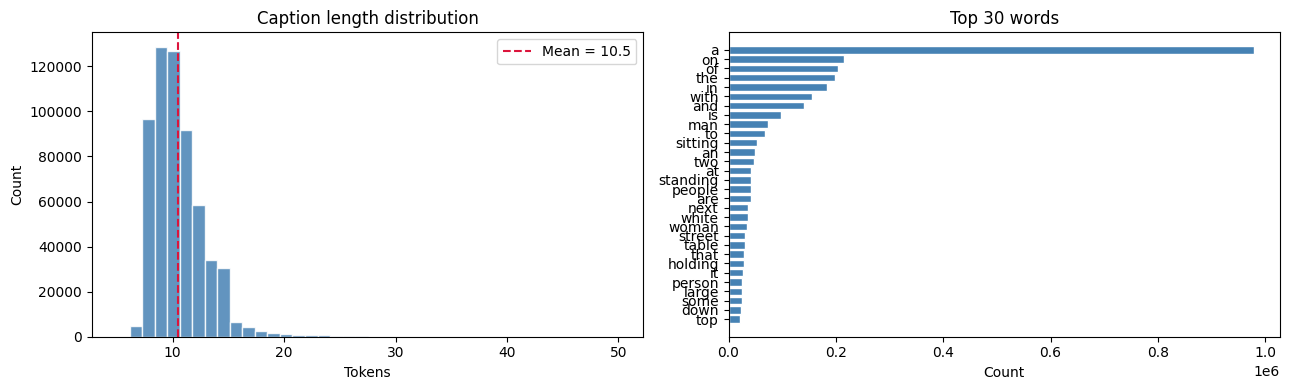

Mean length: 10.5 | 95th pct: 15


In [12]:
lengths = df['caption_clean'].str.split().str.len()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(lengths.mean(), color='crimson', linestyle='--',
                label=f'Mean = {lengths.mean():.1f}')
axes[0].set_xlabel('Tokens'); axes[0].set_ylabel('Count')
axes[0].set_title('Caption length distribution'); axes[0].legend()

top_words = Counter(' '.join(df['caption_clean']).split()).most_common(30)
words, counts = zip(*top_words)
axes[1].barh(words[::-1], counts[::-1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 30 words'); axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()
print(f"Mean length: {lengths.mean():.1f} | 95th pct: {np.percentile(lengths,95):.0f}")

## 5. Build vocabulary  (min freq = 3)

In [13]:
MIN_FREQ = 3
MAX_LEN  = 34    # covers 95th percentile comfortably

word_freq = Counter()
for cap in df['caption_clean']:
    word_freq.update(cap.split())

specials = ['<pad>', '<start>', '<end>', '<unk>']
vocab    = specials + [w for w, c in word_freq.most_common()
                       if c >= MIN_FREQ]
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

print(f"Vocab size       : {len(vocab):,}")
print(f"Words kept       : {sum(1 for c in word_freq.values() if c >= MIN_FREQ):,}")
print(f"Words filtered   : {sum(1 for c in word_freq.values() if c < MIN_FREQ):,}")
print(f"Max seq length   : {MAX_LEN}")

Vocab size       : 13,140
Words kept       : 13,136
Words filtered   : 13,712
Max seq length   : 34


## 6. GloVe 6B 300d — download & build embedding matrix

In [15]:
# Download GloVe (822 MB):
# !wget http://nlp.stanford.edu/data/glove.6B.zip -P data/
# !unzip data/glove.6B.zip -d data/glove/

GLOVE_PATH = 'data/glove/glove.6B.300d.txt'

from models import load_glove
glove_matrix = load_glove(GLOVE_PATH, word2idx, embed_dim=300)
print(f"Embedding matrix : {glove_matrix.shape}")

--2026-05-18 23:35:37--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 

171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-18 23:35:38--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-18 23:35:39--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘data/glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  5.07MB/s    in 2m 40s  

2026-05-18 23:38:20 (5.15 MB/s) - 

## 7. Encode captions → sequences

In [16]:
def encode(caption):
    tokens = ['<start>'] + caption.split()[:MAX_LEN - 2] + ['<end>']
    ids    = [word2idx.get(t, word2idx['<unk>']) for t in tokens]
    ids   += [word2idx['<pad>']] * (MAX_LEN - len(ids))
    return ids[:MAX_LEN]

df['encoded']    = df['caption_clean'].apply(encode)
df['input_seq']  = df['encoded'].apply(lambda x: x[:-1])
df['target_seq'] = df['encoded'].apply(lambda x: x[1:])
print("input_seq length :", len(df['input_seq'].iloc[0]))
print("target_seq length:", len(df['target_seq'].iloc[0]))

input_seq length : 33
target_seq length: 33


## 8. Train / val / test split (by image — no leakage)

In [17]:
images = df['image'].unique()
np.random.seed(42); np.random.shuffle(images)
n = len(images)
train_imgs = set(images[:int(n * 0.90)])
val_imgs   = set(images[int(n * 0.90):int(n * 0.95)])
test_imgs  = set(images[int(n * 0.95):])

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)
test_df  = df[df['image'].isin(test_imgs)].reset_index(drop=True)

print(f"Train : {train_df['image'].nunique():>6,} imgs  {len(train_df):>8,} pairs")
print(f"Val   : {val_df['image'].nunique():>6,} imgs  {len(val_df):>8,} pairs")
print(f"Test  : {test_df['image'].nunique():>6,} imgs  {len(test_df):>8,} pairs")

Train : 106,458 imgs   532,576 pairs
Val   :  5,914 imgs    29,587 pairs
Test  :  5,915 imgs    29,590 pairs


## 9. Save artifacts

In [18]:
os.makedirs('artifacts', exist_ok=True)

artifacts = dict(
    train_df    = train_df,
    val_df      = val_df,
    test_df     = test_df,
    word2idx    = word2idx,
    idx2word    = idx2word,
    vocab_size  = len(vocab),
    glove_matrix= glove_matrix,
    max_len     = MAX_LEN,
)
with open('artifacts/eda_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print("Saved artifacts/eda_artifacts.pkl")
print(f"  vocab_size  : {len(vocab):,}")
print(f"  train pairs : {len(train_df):,}")

Saved artifacts/eda_artifacts.pkl
  vocab_size  : 13,140
  train pairs : 532,576
